In [ ]:
import matplotlib.pyplot as plt 
import os 
os.chdir('../')
import torch
import numpy as np
import torch.nn as nn
from typing import List, Tuple, Optional
import matplotlib.pyplot as plt
import random 
from decimal import Decimal
import deepwave
import warnings
from torchaudio.functional import biquad
from scipy.signal import butter
from torch.utils.tensorboard import SummaryWriter
import torch.nn.functional as F
from functools import partial
import time
from tools.utils import ComputeSNR,ComputeSSIM,ComputeRE
warnings.filterwarnings('ignore')
import os
from tools.regularization import*
from tools.tools import *
os.environ['KMP_DUPLICATE_LIB_OK']='True'

In [2]:
gpu_count = torch.cuda.device_count()
print(f"The number of available GPUs is: {gpu_count}")
if torch.cuda.is_available():
    DEVICE = torch.device("cuda:0")  
    print(f"The selected GPU device is: {torch.cuda.get_device_name(DEVICE)}")
else:
    DEVICE = torch.device("cpu")
    print("No available GPUs detected, switched to using CPU")

The number of available GPUs is: 1
The selected GPU device is: NVIDIA GeForce RTX 4090


vp_true max min tensor(4790., device='cuda:0') tensor(1473.4270, device='cuda:0')


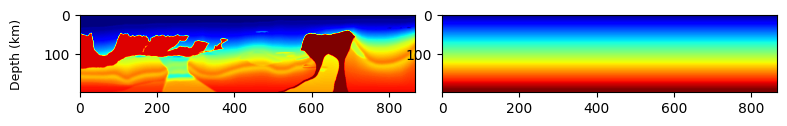

max values: tensor(4790., device='cuda:0')
min values: tensor(1473.4270, device='cuda:0')


In [3]:
### load vp_true and linear initial model
vp_true    = torch.tensor(np.load('./model_data/vp_truex200x868.npy')).to(DEVICE)
vp_initial =  torch.tensor(np.load('./model_data/vp_initx200x868.npy')).to(DEVICE)

dx, dz = 25,25 ## m

### show true and initial
print("vp_true max min",vp_true.max(),vp_true.min())

fig, ax = plt.subplots(1, 2, figsize=(9, 6))
fig1 = ax[0].imshow(vp_true.cpu().numpy(), cmap= 'jet',vmin = vp_true.min(),vmax = vp_true.max())
ax[0].set_ylabel("Depth (km)\n",fontsize=9)
fig2 = ax[1].imshow(vp_initial.cpu().numpy(), cmap= 'jet',vmin = vp_true.min(),vmax = vp_true.max())
plt.subplots_adjust(hspace=-0.84,wspace=0.08) 
plt.show()
print("max values:",vp_true.max())
print("min values:",vp_true.min())

In [4]:
# ==============================================
# Full Waveform Inversion Configuration
# ==============================================
test_low_fre = 'yes'    # Enable low-frequency testing ('yes'/'no')
cutoff_fre = 1.0      # Cutoff frequency for filtering (Hz)
corners = 16.0          # Filter corners/order for frequency testing

# --------------------------
# Noise Testing Parameters  
# --------------------------
test_low_noise = 'yes'  # Enable noise testing ('yes'/'no')
noise_level = 5      # Standard deviation of Gaussian noise to add
# --------------------------
# learning rate  
# --------------------------
learn = 30
# --------------------------
# Optimization Parameters
# --------------------------
mini_batches = 20      # Number of mini-batches for stochastic optimization
ITERATION = 20        # Total number of optimization iterations

# --------------------------
# Loss Function Configuration
# --------------------------
loss_fn = 'l1'  # Options: 'l1', 'l2'
                

# --------------------------
# frequency continune method paramter
# --------------------------
freqs = [3,5,7,10,12,15]


submarine = "no"                              
submarine_deep = 34                              #water layer deep
submarine_vp = 1486.0002


# --------------------------
#  forward parameters
# --------------------------
DT = 0.008                                              
F_PEAK = 6.0                                            
DH = dx                                                  
N_SHOTS = 60                                             
N_SOURCE_PER_SHOT = 1
model_shape = [vp_true.shape[0],vp_true.shape[1]]
NT = 2000

inpa = {
    'ns': N_SHOTS,               # Number of shots
    'nr': 852,
    'dh': dx,                    # Spatial sampling (m)
    'dt': DT,                    # Time sampling (s)
    'nt': NT,                      # Recording duration (s)
    'accuracy': 4,
    'pml_width': [20, 20, 20, 20]
}

# --------------------------
### save path
# --------------------------

vp_save_path = f'./rec/fwi_ms_noise_{noise_level}/'
if not os.path.exists(vp_save_path):
    os.makedirs(vp_save_path)

main_path = f'./log_data/fwi_ms_noise_{noise_level}/'
if not os.path.exists(main_path):
    os.makedirs(main_path)

In [5]:
#### load source receiver position and source wavelet

src_loc = torch.tensor(np.load('./src_rec_loc/src_loc.npy')).to(DEVICE)
rec_loc = torch.tensor(np.load('./src_rec_loc/rec_loc.npy')).to(DEVICE)
src = torch.tensor(np.load('./source/src.npy')).to(DEVICE)

### load obs data
d_obs = torch.tensor(np.load('./obs_data/d_obs.npy')).to(DEVICE)

In [6]:

criteria1 = torch.nn.L1Loss(reduction='sum') ### for model loss
 
vp0 = vp_initial.to(DEVICE)
vp0 = vp0.requires_grad_(True)

optimer = torch.optim.Adam([{'params': [vp0], 'lr': learn,'betas': (0.9, 0.98)}])

all_loss_data = []
all_loss_model =[]
time_each_iter = []
tv_loss = []
SNR = []
cpu_mem_log = [] 
gpu_mem_log = []

Now inversion on freq: 3
Iter 10 = data loss: 10.9999,model loss: 81555240.0000


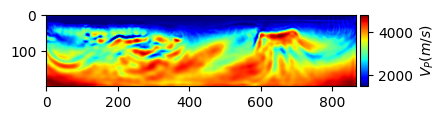

Iter 20 = data loss: 10.7759,model loss: 71189016.0000


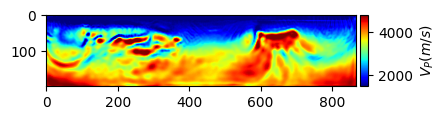

Now inversion on freq: 5
Iter 10 = data loss: 14.0260,model loss: 64051448.0000


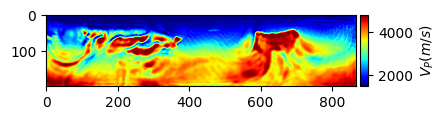

Iter 20 = data loss: 13.9065,model loss: 58490216.0000


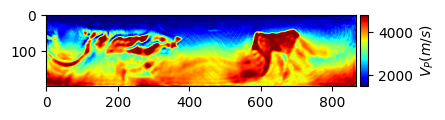

Now inversion on freq: 7
Iter 10 = data loss: 16.6095,model loss: 54461108.0000


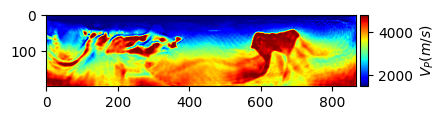

Iter 20 = data loss: 16.4573,model loss: 51658148.0000


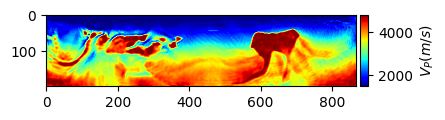

Now inversion on freq: 10
Iter 10 = data loss: 19.6464,model loss: 49823760.0000


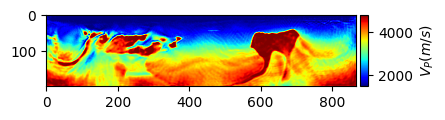

Iter 20 = data loss: 19.5460,model loss: 48865800.0000


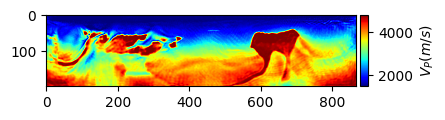

Now inversion on freq: 12
Iter 10 = data loss: 21.1784,model loss: 47267356.0000


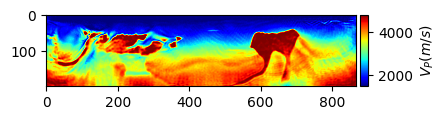

Iter 20 = data loss: 21.1209,model loss: 46627320.0000


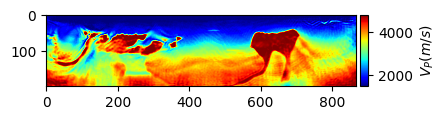

Now inversion on freq: 15
Iter 10 = data loss: 23.3349,model loss: 45667488.0000


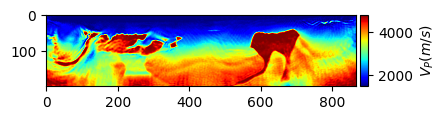

Iter 20 = data loss: 23.1387,model loss: 44846760.0000


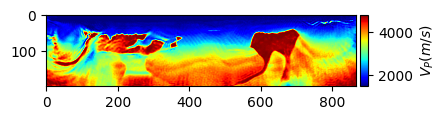

Running complete in 7m  50s


In [7]:

t_start = time.time()

for freq in freqs: 
    print('Now inversion on freq:',freq)
    sos = butter(6, freq, fs=1/DT, output='sos') ## default is low pass
    sos = [torch.tensor(sosi).to(d_obs.dtype).to(DEVICE)
           for sosi in sos]

    def filt(x):
        return biquad(biquad(biquad(x, *sos[0]), *sos[1]), *sos[2])

    for iter in range(ITERATION):
        loss_data_minibatch = []
        time_each_bath_start = time.time()
        for batch in range(mini_batches):
            optimer.zero_grad()
            src_loc_batch = src_loc[batch::mini_batches]
            rec_loc_batch = rec_loc[batch::mini_batches]
            src_batch = src[batch::mini_batches]
                        
            physics = Physics_deepwave(inpa['dh'], inpa['dt'], src=src_batch,
                                src_loc=src_loc_batch, rec_loc=rec_loc_batch,
                                       accuracy = inpa['accuracy'],
                                pml_width =  inpa['pml_width']
                                )
            ### Set maximum and minimum constraints
            with torch.no_grad():
                if submarine == "yes":
                    vp0[:submarine_deep,:] = submarine_vp
                else:
                    vp0 = vp0
                    
                vp0[vp0>vp_true.max()] = vp_true.max()
                vp0[vp0<vp_true.min()] = vp_true.min() 
                
            vp0 = vp0.requires_grad_(True)
            taux_est = physics(vp0.squeeze())
            d_obs1 = d_obs.unsqueeze(0)
      
            taux_est_filtered = filt(taux_est.squeeze(0).permute(0, 2, 1)).permute(0, 2, 1).to(DEVICE).unsqueeze(0)
            d_obs_filtered = filt(d_obs1[:, batch::mini_batches].squeeze(0).permute(0, 2, 1)).permute(0, 2, 1).to(DEVICE).unsqueeze(0)
            
            lam_tv = 0#0.0001
            tvloss = tv_l1_regularization(vp0)
            if loss_fn == 'l1':
                criteria = torch.nn.L1Loss(reduction='mean')
            if loss_fn == 'l2':
                criteria = torch.nn.MSELoss(reduction='mean')
                
            loss_data = 1.0e2*criteria(taux_est_filtered, d_obs_filtered)+lam_tv*tvloss
            loss = loss_data
            loss.backward()
            optimer.step()
              
        all_loss_data.append(np.mean(loss.item()))
        time_each_bath_end = time.time()
        tv_loss.append(lam_tv*tvloss)
        
        time_each_iter.append(time_each_bath_end - time_each_bath_start)
        
        mem_now_cpu = get_cpu_memory()
        cpu_mem_log.append(mem_now_cpu)
        mem_now_gpu = get_gpu_memory()
        gpu_mem_log.append(mem_now_gpu)
        
        snr = ComputeSNR(vp0.detach().cpu().numpy(), \
                      vp_true.detach().cpu().numpy())
        SNR = np.append(SNR, snr)
        
        with torch.no_grad():
            all_loss_model.append(
                criteria1(vp0, vp_true).item()
            )
        if (iter+1)%10 ==0:
            print(f"Iter {iter + 1} = data loss: {all_loss_data[-1]:.4f},model loss: {all_loss_model[-1]:.4f}")
        if (iter+1)%10 ==0:
            np.save(vp_save_path + 'recx_iter_%s_freq_%s.npy' % (iter + 1, freq), vp0.cpu().detach().numpy())
        if (iter+1)%10 == 0:
            fig, ax = plt.subplots(1,1, figsize=(4, 4))
            im = ax.imshow(vp0.detach().cpu(), 
                              cmap='jet', vmin=vp_true.min(), 
                       vmax=vp_true.max()) 
            points = ax.get_position().get_points()
            dy = points[1, 1] - points[0, 1]
    
            cax = fig.add_axes([0.91, points[0, 1], 0.02, dy])
            cax.yaxis.set_ticks_position("right")
            cbar = fig.colorbar(im, cax=cax, orientation="vertical", 
                                extend="neither", label="$V_P (m/s)$"
                                )
            plt.show()
t_end = time.time()
elapsed_time = t_end - t_start
print('Running complete in {:.0f}m  {:.0f}s' .format(elapsed_time //60 , elapsed_time % 60))

In [8]:
with torch.no_grad():
    np.savetxt(main_path +'all_loss_data.txt', all_loss_data,delimiter=',')
    np.savetxt(main_path +'elapsed_time.txt', time_each_iter,delimiter=',')
    np.savetxt(main_path + 'all_loss_model.txt', all_loss_model, delimiter=',')
    np.savetxt(main_path + 'snr.txt', SNR, delimiter=',')
    np.savetxt(main_path+'cpu_men_log.txt',cpu_mem_log , delimiter=',')
    np.savetxt(main_path+'gpu_men_log.txt',gpu_mem_log , delimiter=',')

In [9]:
torch.cuda.empty_cache()